In [29]:
from sklearn import svm, model_selection
import pandas as pd
import numpy as np
# https://scikit-learn.org/stable/model_persistence.html
# Joblib offers alternative pickle load and dump functions
# which is more efficient for sklearn models
from joblib import load, dump
import pickle

In [30]:
# Select a subset of ratios as model features
df = pd.read_pickle("ratios.pkl")
df = df[["stopword_ratio", "punctuation_ratio", "token_ratio", "upper_ratio", "upper_to_punct_ratio"]]
df = df.astype(float)

In [31]:
X = df.to_numpy()
idx = range(len(X))

In [32]:
X_train, X_test, idx_train, idx_test = model_selection.train_test_split(X, idx, test_size=0.2)

In [33]:
clf = svm.OneClassSVM(nu=0.05)
clf.fit(X_train)

OneClassSVM(nu=0.05)

In [34]:
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

In [35]:
labels = pd.DataFrame(list(zip(idx_test, y_pred_test)), columns=["index", "class"])
labels.set_index('index', inplace=True)

In [36]:
d = pd.read_pickle("ratios.pkl")["original_text"].iloc[idx_test]

In [37]:
pred = pd.concat([d, labels], axis=1)

In [38]:
pred[pred['class'] == -1]

,original_text,class
4110,Schiedsrichter Carlos Ramos im Disput mit Sere...,-1
5178,Großer schwanz Tätowiert Von hinten Große type...,-1
10805,Weitere Auswahlkriterien waren unter anderem d...,-1
2436,"Ich bin schon so gespannt auf meine Zeta, ich ...",-1
8607,Klassische Stiefeletten Klassische schwarz sch...,-1
...,...,...
3668,Der Firmensitz der Firma selbst ist in Düsseld...,-1
4512,"Behindertenausweis wurde ""erhöht"" undrückwirke...",-1
8002,Online Flirten In Kostenloser Tit Sex Amateur ...,-1
10903,Hallo habe über vlc einem tag die senderliste ...,-1


In [39]:
pred[pred['class'] == -1].to_csv('pred.csv')

## Evaluation

In [40]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# load labelled data
pd_label_studio = pd.read_json('label_studio-min.json')

# merge with groundtruth data
df_merge = pd.merge(pd_label_studio.reset_index()[['index','sentiment']], pred.reset_index(), on='index')
df_merge['sentiment'] = df_merge['sentiment'].replace('mixed', -1).replace('spam', -1).replace('clean', 1)

y_test = df_merge['sentiment']
y_test_predictions = df_merge['class']

conf_matrix = confusion_matrix(y_test, y_test_predictions)
conf_matrix

array([[  7,  10],
       [  5, 250]])

### Plot

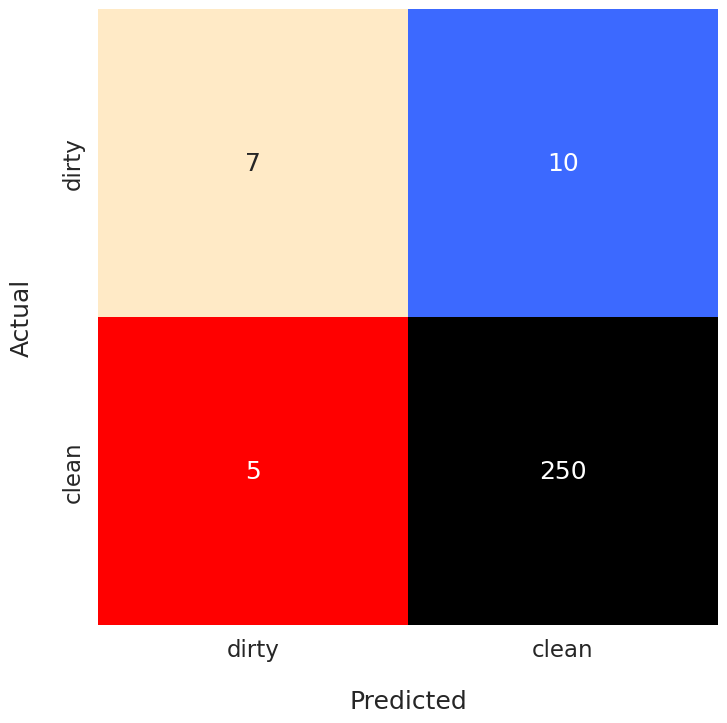

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))
sns.set(font_scale = 1.5)

# TODO: beatyfy this by adding meaningful labels, i.e. not 0 and 1, but clean and dirty

ax = sns.heatmap(
    conf_matrix, # confusion matrix 2D array
    annot=True, # show numbers in the cells
    fmt='d', # show numbers as integers
    cbar=False, # don't show the color bar
    cmap='flag', # customize color map
    vmax=175, # to get better color contrast,
    xticklabels = ['dirty', 'clean'],
    yticklabels = ['dirty', 'clean']
)

ax.set_xlabel("Predicted", labelpad=20)
ax.set_ylabel("Actual", labelpad=20)

plt.show()

### Metrics

In [46]:
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, y_test_predictions)
precision = precision_score(y_test, y_test_predictions)
recall = recall_score(y_test, y_test_predictions)
f1score = f1_score(y_test, y_test_predictions)

print(f"Accuracy = {accuracy.round(4)}")
print(f"Precision = {precision.round(4)}")
print(f"Recall = {recall.round(4)}")
print(f"F1 Score = {f1score.round(4)}")

print(classification_report(y_test, y_test_predictions, target_names=['dirty', 'clean']))

## TODO: ROC
from sklearn.metrics import roc_curve




Accuracy = 0.9449
Precision = 0.9615
Recall = 0.9804
F1 Score = 0.9709
              precision    recall  f1-score   support

       dirty       0.58      0.41      0.48        17
       clean       0.96      0.98      0.97       255

    accuracy                           0.94       272
   macro avg       0.77      0.70      0.73       272
weighted avg       0.94      0.94      0.94       272



## Saving the model

In [ ]:
out_path = 'oneclasssvm.joblib'
dump(clf, out_path)

['oneclasssvm.joblib']